In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import sys
import os

PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

from data.schema_selected import *

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load dataset

In [55]:
df = pd.read_parquet('../data/selected_schema_data.parquet')

df.drop(columns=index_cols, inplace=True)

# Data Quality Overview

Analyze missing values before processing


=== MISSING VALUES BEFORE IMPUTATION ===
fup_ccs               4382
pci_platelvol_ldis    3273
fup_nyha              2736
pci_platelvol_pre     2550
pci_tropo_ldis        2544
pci_tropo_pre         2257
pci_glycemia          1290
pci_platel_pre         892
pci_creatinine_pre     832
proir_avs_yn           459
lvef                   282
contrast                41
bp_sys                  17
alcohol                 16
smoker                  13
heartrate                9
prec_wbc                 1
dtype: int64

Total rows with missing values: 4568 (99.76%)


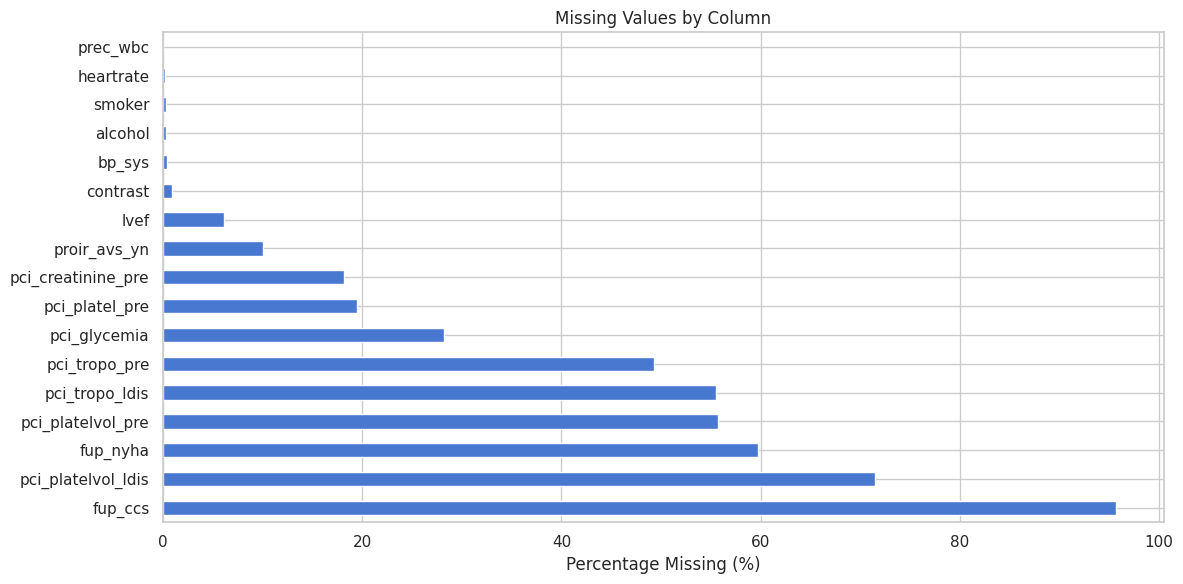


Total cells with missing data: 21594 out of 251845


In [56]:
# Analyze missing values
print("=== MISSING VALUES BEFORE IMPUTATION ===")
null_columns = df.isnull().sum().sort_values(ascending=False)
print(null_columns[null_columns > 0])
print(f"\nTotal rows with missing values: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)")

# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(12, 6))
missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_data[missing_data > 0].plot(kind='barh', ax=ax)
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

print(f"\nTotal cells with missing data: {df.isnull().sum().sum()} out of {df.shape[0] * df.shape[1]}")


In [57]:
def drop_highly_missing(df, threshold=0.5):
    """Drop columns with missing values above the specified threshold."""
    missing_percent = df.isnull().mean()
    cols_to_drop = missing_percent[missing_percent > threshold].index
    print(f"Dropping columns with more than {threshold*100:.0f}% missing values: {list(cols_to_drop)}")
    print(f"Total columns dropped: {len(cols_to_drop)}")
    with open("../data/removed_columns.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(cols_to_drop))
    return df.drop(columns=cols_to_drop)

drop_threshold = 0.4
df = drop_highly_missing(df, threshold=drop_threshold)

numeric = df.select_dtypes(include=[np.number]).columns.difference(target_cols)

Dropping columns with more than 40% missing values: ['pci_tropo_pre', 'fup_nyha', 'pci_platelvol_pre', 'pci_platelvol_ldis', 'pci_tropo_ldis', 'fup_ccs']
Total columns dropped: 6


In [58]:
# NOTE: imputation is DEFERRED to the modeling pipelines.
# Median/mode imputation fit on the full cohort here would leak test-set
# statistics into the features (the train/test split happens downstream).
# Instead, predictive notebooks add a SimpleImputer as the first pipeline
# step, fit on the training split (and each CV fold) only.
#
# Numeric NaNs are intentionally left in place and saved as-is. Categorical
# NaNs are handled deterministically by one-hot encoding below (dummy_na=False
# maps a missing category to an all-zero indicator row), which is not leakage.
print("=== MISSING VALUES (left for pipeline imputation) ===")
remaining = df[numeric].isnull().sum()
print(remaining[remaining > 0].sort_values(ascending=False))
print(f"\nTotal numeric cells still missing: {int(df[numeric].isnull().sum().sum())}")
print(df.head())

=== MISSING VALUES (left for pipeline imputation) ===
pci_glycemia          1290
pci_platel_pre         892
pci_creatinine_pre     832
lvef                   282
contrast                41
bp_sys                  17
heartrate                9
prec_wbc                 1
dtype: int64

Total numeric cells still missing: 3364
   cec_barc235_335d  cec_cvdeath_335d  cec_mi_335d  cec_stroke_335d  \
0                 0                 0            0                0   
1                 0                 0            0                0   
2                 0                 0            0                0   
3                 0                 0            0                0   
4                 0                 0            0                0   

   cec_bleed_335d  cec_barc2_335d  cec_barc3_335d  cec_barc35_335d  \
0               0               0               0                0   
1               0               0               0                0   
2               0               0      

# Imputing Values

Imputation is **deferred** to the modeling pipelines (a `SimpleImputer` fit on the
training split only) to avoid leaking test-set statistics. Numeric NaNs are left
in place here; categorical NaNs are absorbed by one-hot encoding (`dummy_na=False`).

# Variable Encoding

In [59]:
import re

print("=== VARIABLE ENCODING ===")

# 1. Binary encoding for gender
print("Encoding gender...")
df['gender_encoded'] = (df['gender'] == 'Male').astype(int)
df.drop(['gender'], axis=1, inplace=True)

# 2. One-hot encoding for categorical variables
categorical_scheme = categorical.copy()
categorical_scheme.remove('gender')

print(f"One-hot encoding {len(categorical_scheme)} categorical variables...")
onehot_cols = pd.get_dummies(df[categorical_scheme], prefix=categorical_scheme, drop_first=True, 
                             dtype=int, dummy_na=False, prefix_sep='_', sparse=False)

# 3. Shorten one-hot column names: free-text category values (e.g. p_bleed_action1's
# long descriptions) produce unwieldy names that break tools expecting short feature
# names, so trim each name to its meaningful part within MAX_COL_NAME_LEN chars.
MAX_COL_NAME_LEN = 20


def shorten_column_name(name, max_len=MAX_COL_NAME_LEN):
    if len(name) <= max_len:
        return name
    cleaned = re.sub(r'\([^)]*\)', '', name)          # drop parenthetical asides
    cleaned = re.sub(r'[^0-9a-zA-Z]+', '_', cleaned).strip('_').lower()
    if len(cleaned) <= max_len:
        return cleaned
    words = cleaned.split('_')
    short = words[0]
    for word in words[1:]:
        if len(short) + 1 + len(word) <= max_len:
            short += '_' + word
        else:
            remaining = max_len - len(short) - 1
            if remaining > 0:
                short += '_' + word[:remaining]
            break
    return short[:max_len]


def dedupe_names(names, max_len=MAX_COL_NAME_LEN):
    seen = {}
    result = []
    for name in names:
        count = seen.get(name, 0)
        seen[name] = count + 1
        if count == 0:
            result.append(name)
        else:
            suffix = str(count)
            result.append(f"{name[:max_len - len(suffix)]}{suffix}")
    return result


rename_map = {col: shorten_column_name(col) for col in onehot_cols.columns}
onehot_cols = onehot_cols.rename(columns=rename_map)
onehot_cols.columns = dedupe_names(onehot_cols.columns)

long_renames = {old: new for old, new in rename_map.items() if old != new}
print(f"Shortened {len(long_renames)} long one-hot column names (max {MAX_COL_NAME_LEN} chars):")
for old, new in long_renames.items():
    print(f"  {old!r}\n    -> {new!r}")

# Create final encoded dataframe
df = pd.concat([df.drop(columns=categorical_scheme), onehot_cols], axis=1)

print(f"Shape after encoding: {df.shape}")
print(f"Number of columns: {df.shape[1]}")
print("\nNew columns from one-hot encoding:")
print([col for col in onehot_cols.columns])


=== VARIABLE ENCODING ===
Encoding gender...
One-hot encoding 10 categorical variables...
Shortened 26 long one-hot column names (max 20 chars):
  'afib_yes - long-standing persistent'
    -> 'afib_yes_long_standi'
  'afib_yes - paroxysmal'
    -> 'afib_yes_paroxysmal'
  'afib_yes - persistent'
    -> 'afib_yes_persistent'
  'alcohol_unknown - the patient does not want to answer'
    -> 'alcohol_unknown_the'
  'alcohol_yes - eight beers and equivalent per week or more'
    -> 'alcohol_yes_eight_be'
  'alcohol_yes - less than eight beers or equivalent per week'
    -> 'alcohol_yes_less_tha'
  'alcohol_yes - unknown consumption per week'
    -> 'alcohol_yes_unknown'
  'diabetes_type I-insulin dependent'
    -> 'diabetes_type_i_insu'
  'diabetes_type II diet'
    -> 'diabetes_type_ii_die'
  'diabetes_type II insulin'
    -> 'diabetes_type_ii_ins'
  'diabetes_type II insulin and oral drugs'
    -> 'diabetes_type_ii_ins'
  'diabetes_type II oral drugs'
    -> 'diabetes_type_ii_ora'
  'geogr

In [60]:
print("=== FEATURE-TARGET SEPARATION ===\n")

# Separate features and targets
X = df.drop(columns=target_cols)
y = df[target_cols]

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")

print(f"\nFeature names ({X.shape[1]}):")
print(list(X.columns))

print(f"\nTarget statistics:")
print(y.describe())

# Check class balance for target variables
print("\nTarget class distribution:")
for target in target_cols[:3]:  # Show first 3 targets
    distribution = y[target].value_counts()
    print(f"\n{target}:")
    print(distribution)
    print(f"Ratio: {(distribution / len(y) * 100).round(2).to_dict()}")

# Save cleaned dataset and components
output_dir = '../data/'
os.makedirs(output_dir, exist_ok=True)

# Save full dataset
df.to_parquet(os.path.join(output_dir, 'data_cleaned.parquet'), index=False)
print(f"\n✓ Full cleaned dataset saved: {output_dir}data_cleaned.parquet")

# Save features and targets separately
X.to_parquet(os.path.join(output_dir, 'X_features.parquet'), index=False)
y.to_parquet(os.path.join(output_dir, 'y_targets.parquet'), index=False)
print(f"✓ Features saved: {output_dir}X_features.parquet")
print(f"✓ Targets saved: {output_dir}y_targets.parquet")

# Save metadata
metadata = {
    'n_samples': X.shape[0],
    'n_features': X.shape[1],
    'n_targets': y.shape[1],
    'feature_names': list(X.columns),
    'target_names': list(y.columns),
    'numeric_features_scaled': list(numeric),
    'categorical_features_encoded': len([col for col in df.columns if col.endswith('_1')])
}

import json
with open(os.path.join(output_dir, 'dataset_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {output_dir}dataset_metadata.json")

print(f"\n=== DATA CLEANING COMPLETE ===")
print(f"Ready for modeling with {X.shape[0]} samples and {X.shape[1]} features")


=== FEATURE-TARGET SEPARATION ===

Features shape: (4579, 64)
Targets shape: (4579, 9)

Feature names (64):
['fup_other', 'rand_oac12', 'cancer', 'prec_priorbleed', 'p_bleed', 'rand_ster_nsaid', 'rand_anemia', 'fup_nitrates', 'fup_insulin', 'prior_cabg', 'prior_mi_12m', 'cad', 'hyperlipidemia', 'regimen', 'ic_age_mon', 'pci_platel_pre', 'lvef', 'heartrate', 'pci_glycemia', 'prec_hb', 'pci_creatinine_pre', 'prec_wbc', 'bmi', 'prior_mi', 'bp_sys', 'contrast', 'prior_pci', 'prec_creatinine', 'height', 'gender_encoded', 'afib_yes_long_standi', 'afib_yes_paroxysmal', 'afib_yes - permanent', 'afib_yes_persistent', 'alcohol_unknown_the', 'alcohol_yes_eight_be', 'alcohol_yes_less_tha', 'alcohol_yes_unknown', 'diabetes_type_i_insu', 'diabetes_type_ii_die', 'diabetes_type_ii_ins', 'diabetes_type_ii_in1', 'diabetes_type_ii_ora', 'geography_australia', 'geography_Europe', 'p_bleed_action1_rece', 'p_bleed_action1_none', 'proir_avs_yn_yes', 'acs_last_pci_acs_ste', 'acs_last_pci_acs_uns', 'acs_last_p

# Feature-Target Separation and Export

Separate features from targets and save the cleaned dataset


Target columns available: 9
['cec_barc235_335d', 'cec_cvdeath_335d', 'cec_mi_335d', 'cec_stroke_335d', 'cec_bleed_335d', 'cec_barc2_335d', 'cec_barc3_335d', 'cec_barc35_335d', 'cec_revasc_335d']

Top 10 features correlated with cec_barc235_335d:
cec_barc2_335d     0.83
cec_bleed_335d     0.83
cec_barc35_335d    0.57
cec_barc3_335d     0.54
cec_cvdeath_335d   0.11
cec_stroke_335d    0.11
rand_oac12         0.08
cec_mi_335d        0.07
fup_other          0.06
ic_age_mon         0.06
Name: cec_barc235_335d, dtype: float64


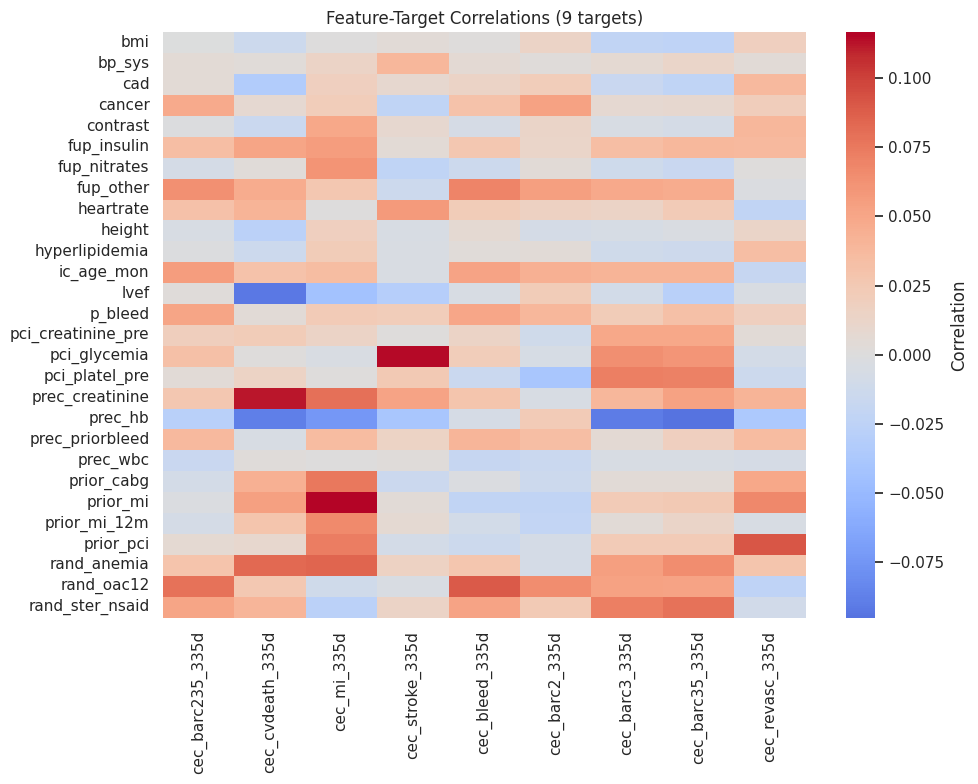

In [61]:
# Correlation with target outcomes
target_cols_present = [col for col in target_cols if col in df.columns]
print(f"Target columns available: {len(target_cols_present)}")
print(target_cols_present)

if len(target_cols_present) > 0:
    # Calculate correlations
    correlations = df[list(numeric) + target_cols_present].corr()
    
    # Get top correlations with first target
    first_target = target_cols_present[0]
    top_corr = correlations[first_target].sort_values(ascending=False)[1:11]

    print(f"\nTop 10 features correlated with {first_target}:")
    print(top_corr)
    
    # Visualize correlation matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlations.iloc[:len(numeric), -len(target_cols_present):], 
                cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Correlation'}, ax=ax)
    ax.set_title(f'Feature-Target Correlations ({len(target_cols_present)} targets)')
    plt.tight_layout()
    plt.show()


# Correlation Analysis

Analyze correlations between features and targets


In [62]:
print("=== DATA QUALITY REPORT ===\n")

# Check for any remaining NaN values
print(f"1. Numeric missing values (left for pipeline imputation): "
      f"{int(df.isnull().sum().sum())}")

# Check data types
print(f"\n2. Data types:")
print(df.dtypes.value_counts())

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\n3. Infinite values: {inf_count} (should be 0)")

# Check dimensions
print(f"\n4. Final dataset shape: {df.shape}")
print(f"   - Features: {df.shape[1]}")
print(f"   - Samples: {df.shape[0]}")

# Statistical summary
print(f"\n5. Feature statistics:")
print(df.describe().T[['mean', 'std', 'min', 'max']])

# Distribution check
print(f"\n6. Feature distribution check:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"   - Numeric features: {len(numeric_cols)}")
print(f"   - Binary/categorical features: {df.shape[1] - len(numeric_cols)}")

# Check balance of binary features
binary_cols = [col for col in df.columns if set(df[col].unique()).issubset({0, 1})]
print(f"\n7. Binary feature balance (sample):")
for col in binary_cols[:5]:
    ratio = df[col].mean()
    print(f"   - {col}: {ratio*100:.1f}% ones")


=== DATA QUALITY REPORT ===

1. Numeric missing values (left for pipeline imputation): 3364

2. Data types:
int64       35
Int8        24
float64     12
int16        1
category     1
Name: count, dtype: int64

3. Infinite values: 0 (should be 0)

4. Final dataset shape: (4579, 73)
   - Features: 73
   - Samples: 4579

5. Feature statistics:
                     mean  std  min  max
cec_barc235_335d     0.08 0.27 0.00 1.00
cec_cvdeath_335d     0.02 0.13 0.00 1.00
cec_mi_335d          0.02 0.15 0.00 1.00
cec_stroke_335d      0.01 0.09 0.00 1.00
cec_bleed_335d       0.11 0.31 0.00 1.00
...                   ...  ...  ...  ...
race_African origin  0.00 0.06 0.00 1.00
race_Asian origin    0.10 0.30 0.00 1.00
race_caucasian_origi 0.80 0.40 0.00 1.00
race_native_american 0.00 0.02 0.00 1.00
race_race_is_not_col 0.09 0.29 0.00 1.00

[72 rows x 4 columns]

6. Feature distribution check:
   - Numeric features: 72
   - Binary/categorical features: 1

7. Binary feature balance (sample):
   - cec_ba

## ⚠️ Important: Preprocessing Strategy

**DO NOT scale or impute features at this stage!**

Both **imputation** and **feature scaling** are applied **AFTER** the train-test
split, inside the modeling pipeline, to avoid data leakage:
- Fit the imputer and scaler only on the training set (and each CV fold)
- Apply them to the held-out/test set without refitting
- This ensures test-set statistics never influence the fitted transforms

The cleaned feature matrix is therefore saved with numeric NaNs preserved; the
`SimpleImputer` + `RobustScaler` steps live in the modeling notebooks.

# Data Quality Assessment

Validate the cleaned dataset
